#**스마트폰 센서 데이터 기반 모션 분류**
# 단계3 : 단계별 모델링


## 0.미션4

* 단계별로 나눠서 모델링을 수행하고자 합니다.  
* 단계 구분 예시
    * 단계1 : 정적(0), 동적(1) 행동 분류 모델 생성
    * 단계2 : 세부 동작에 대한 분류모델 생성
        * 단계1 모델에서 0으로 예측 -> 정적 행동 3가지 분류 모델링
        * 단계1 모델에서 1으로 예측 -> 동적 행동 3가지 분류 모델링
* 모델 통합
    * 두 단계 모델을 통합하고, 새로운 데이터에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
* 성능 비교
    * 기본 모델링의 성능과 비교
    * 성능 가이드
        * Accuracy : 0.97 ~ 0.99
* 파이프라인 구성
    * test 데이터를 입력하여, 전처리 및 예측결과가 나오도록 함수 구성

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Deep_Learning/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Dropout
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l1, l2

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [ ]:
train_data = pd.read_csv(path + 'data01_train.csv')
test_data = pd.read_csv(path + 'data01_test.csv')
feature_data = pd.read_csv(path + 'features.csv')

In [ ]:
drop_cols = 'subject'

In [ ]:
train_data.drop(columns=drop_cols, inplace=True)
test_data.drop(columns=drop_cols, inplace=True)

#### 2) 기본 정보 조회

In [ ]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [ ]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [ ]:
train_data.shape

(5881, 562)

## 2.데이터 전처리

* 세부 요구사항
    - Label 추가 : 1단계 모델을 위한 레이블 추가
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

### (1) 1단계 모델링을 위한 레이블

In [ ]:
data_d = train_data.copy()

data_d['is_dynamic'] = np.where(data_d['Activity'].isin(['STANDING', 'SITTING', 'LAYING']), 0, 1)
data_d.drop(columns='Activity', inplace=True)

data_d.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,1


### (2) x, y 분리

In [ ]:
target = 'is_dynamic'

x = data_d.drop(columns=target)
y = data_d[target]

### (3) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [ ]:
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x)

### (4) 데이터 분할
* train, val 분할

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

## **3.단계별 모델링**

### (1) 단계1

* 세부 요구사항
    * 적절한 단계로 구분한 후, 1단계를 분류하는 모델 생성
        * 예시 : 정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성.
    * 몇 가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
nfeatures = x_train.shape[1]

#### 1) 모델1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)

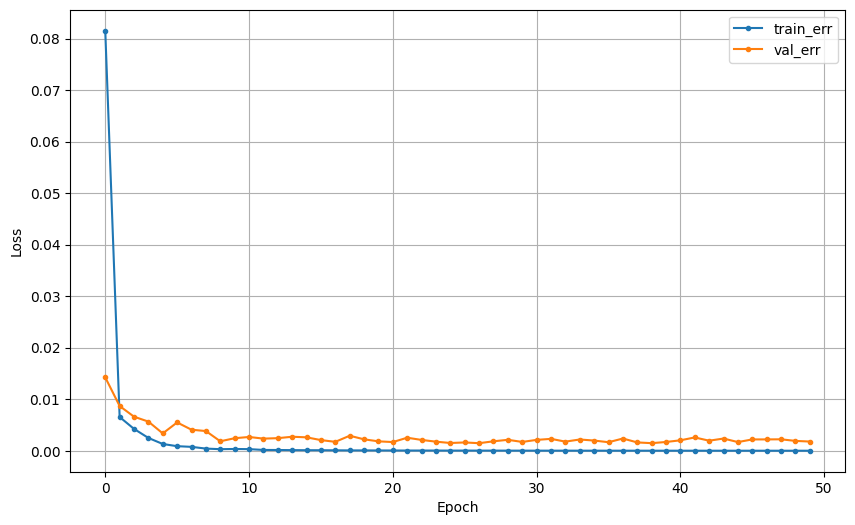

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       957
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765

[[957   0]
 [  0 808]]


In [ ]:
clear_session()

model1 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(1, activation='sigmoid')])

model1.summary()

model1.compile(optimizer=Adam(0.001), loss='binary_crossentropy')

result1 = model1.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

dl_history_plot(result1)

pred1 = model1.predict(x_val)
pred1 = np.where(pred1 > 0.5, 1, 0)

print(accuracy_score(y_val, pred1))
print(classification_report(y_val, pred1))
print(confusion_matrix(y_val, pred1))

In [ ]:
accuracies = []

for _ in range(5):
  clear_session()

  model1 = Sequential([Input(shape=(nfeatures,)),
                      Dense(64, activation='relu'),
                      Dense(16, activation='relu'),
                      Dense(1, activation='sigmoid')])

  model1.summary()

  model1.compile(optimizer=Adam(0.001), loss='binary_crossentropy')

  model1.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0)

  pred1 = model1.predict(x_val)
  pred1 = np.where(pred1 > 0.5, 1, 0)

  accuracies.append(accuracy_score(y_val, pred1))

accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[1.0, 1.0, 1.0, 1.0, 1.0]

#### 2) 모델2

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         143,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,377 (630.38 KB)

 Trainable params: 161,377 (630.38 KB)

 Non-trainable params: 0 (0.00 B)

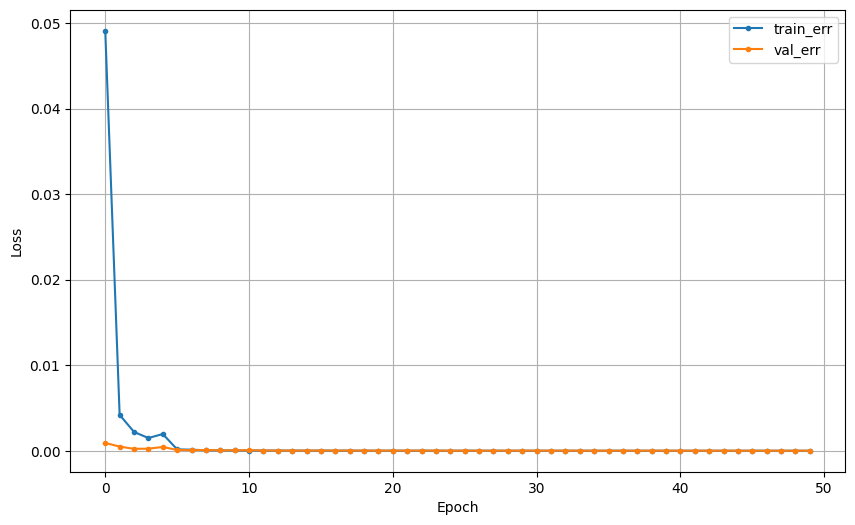

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
0.9994334277620397
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       954
           1       1.00      1.00      1.00       811

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765

[[953   1]
 [  0 811]]


In [ ]:
clear_session()

model2 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(1, activation='sigmoid')])

model2.summary()

model2.compile(optimizer=Adam(0.001), loss='binary_crossentropy')

result2 = model2.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

dl_history_plot(result2)

pred2 = model2.predict(x_val)
pred2 = np.where(pred1 > 0.5, 1, 0)

print(accuracy_score(y_val, pred2))
print(classification_report(y_val, pred2))
print(confusion_matrix(y_val, pred2))

### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* 세부 요구사항
    * 정적 행동(Laying, Sitting, Standing)인 데이터 추출
    * Laying, Sitting, Standing 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
static_act = ['LAYING', 'SITTING', 'STANDING']

data_st = train_data[train_data['Activity'].isin(static_act)]

x_s = data_st.drop(columns='Activity')
y_s = data_st['Activity']

In [ ]:
scaler = MinMaxScaler()
x_scaled_s = scaler.fit_transform(x_s)

encoder = LabelEncoder()

y_enc = encoder.fit_transform(y_s)

x_train_s, x_val_s, y_train_s, y_val_s = train_test_split(x_scaled_s, y_enc, test_size=0.3, random_state=42)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │           1,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,686 (6.59 KB)

 Trainable params: 1,686 (6.59 KB)

 Non-trainable params: 0 (0.00 B)

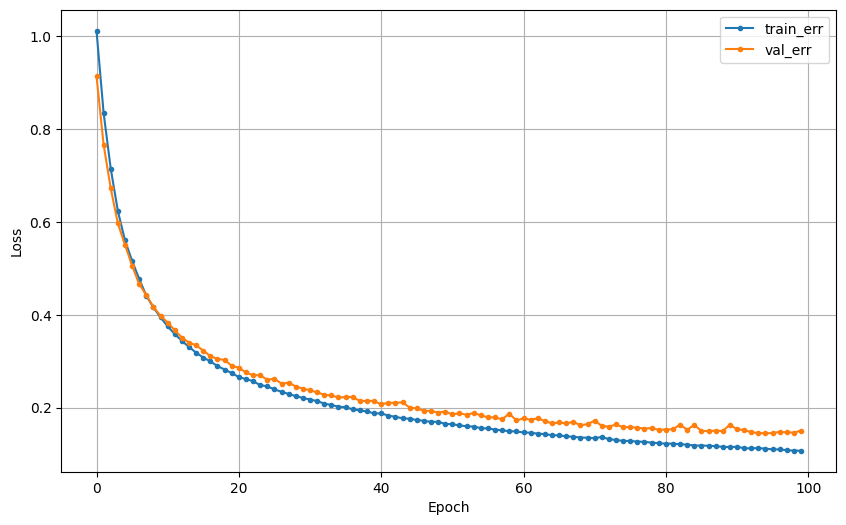

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.9660144181256437
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       338
           1       0.97      0.92      0.95       310
           2       0.93      0.98      0.95       323

    accuracy                           0.97       971
   macro avg       0.97      0.96      0.97       971
weighted avg       0.97      0.97      0.97       971

[[338   0   0]
 [  2 285  23]
 [  0   8 315]]


In [ ]:
clear_session()

model_s1 = Sequential([Input(shape=(nf,)),
                       Dense(3, activation='softmax')
                       ])

model_s1.summary()

model_s1.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

result_s1 = model_s1.fit(x_train_s, y_train_s, epochs=100, validation_split=0.2, verbose=0).history

dl_history_plot(result_s1)

pred_s1 = model_s1.predict(x_val_s)
pred_s1 = np.argmax(pred_s1, axis=1)

print(accuracy_score(y_val_s, pred_s1))
print(classification_report(y_val_s, pred_s1))
print(confusion_matrix(y_val_s, pred_s1))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,059 (144.76 KB)

 Trainable params: 37,059 (144.76 KB)

 Non-trainable params: 0 (0.00 B)

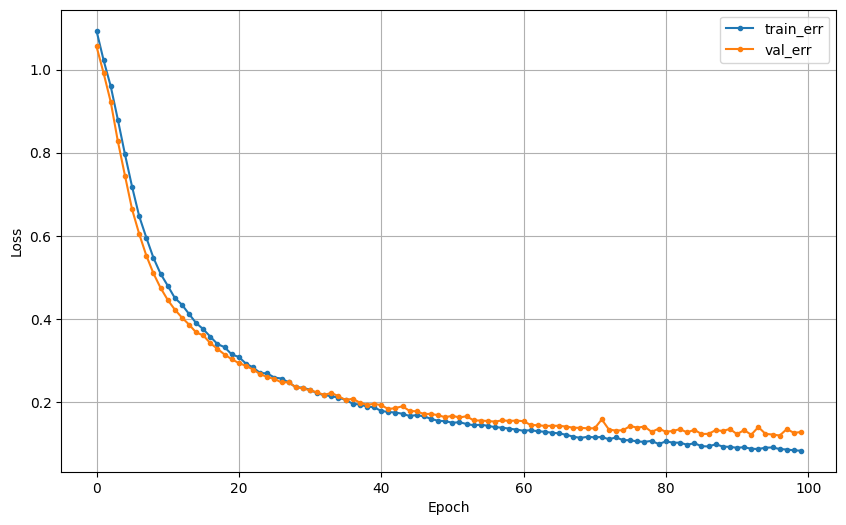

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
0.972193614830072
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       338
           1       0.97      0.94      0.96       310
           2       0.95      0.98      0.96       323

    accuracy                           0.97       971
   macro avg       0.97      0.97      0.97       971
weighted avg       0.97      0.97      0.97       971

[[338   0   0]
 [  1 291  18]
 [  0   8 315]]


In [ ]:
clear_session()

model_s2 = Sequential([Input(shape=(nf,)),
                       Dense(64, activation='relu'),
                       Dropout(0.1),
                       Dense(16, activation='relu'),
                       Dense(3, activation='softmax')
                       ])

model_s2.summary()

model_s2.compile(optimizer=Adam(0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

min_de = 0.0001
pat = 20

es = EarlyStopping(monitor='val_loss', min_delta=min_de, patience=pat)

result_s2 = model_s2.fit(x_train_s, y_train_s, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

dl_history_plot(result_s2)

pred_s2 = model_s2.predict(x_val_s)
pred_s2 = np.argmax(pred_s2, axis=1)

print(accuracy_score(y_val_s, pred_s2))
print(classification_report(y_val_s, pred_s2))
print(confusion_matrix(y_val_s, pred_s2))


#### 2) 단계2-2 : 동적 동작 세부 분류

* 세부 요구사항
    * 동동적 행동(Walking, Walking Upstairs, Walking Downstairs)인 데이터 추출
    * Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
dynamic_act = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

data_dy = train_data[train_data['Activity'].isin(dynamic_act)]

x_d = data_dy.drop(columns='Activity')
y_d = data_dy['Activity']

In [ ]:
scaler = MinMaxScaler()
x_scaled_d = scaler.fit_transform(x_d)

encoder = LabelEncoder()

y_enc = encoder.fit_transform(y_d)

x_train_d, x_val_d, y_train_d, y_val_d = train_test_split(x_scaled_d, y_enc, test_size=0.3, random_state=42)

In [ ]:
len(y_val_d)

795

In [ ]:
nf = x_train_d.shape[1]
nf

561

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │           1,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,686 (6.59 KB)

 Trainable params: 1,686 (6.59 KB)

 Non-trainable params: 0 (0.00 B)

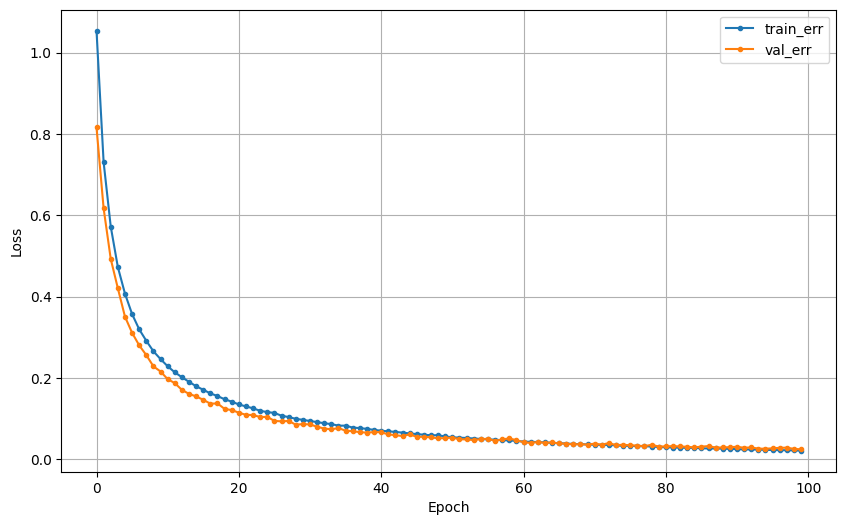

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
0.9924528301886792
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       287
           1       0.99      1.00      1.00       241
           2       0.99      0.99      0.99       267

    accuracy                           0.99       795
   macro avg       0.99      0.99      0.99       795
weighted avg       0.99      0.99      0.99       795

[[283   2   2]
 [  0 241   0]
 [  2   0 265]]


In [ ]:
clear_session()

model_d1 = Sequential([Input(shape=(nf,)),
                       Dense(3, activation='softmax')
                       ])

model_d1.summary()

model_d1.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

result_d1 = model_d1.fit(x_train_d, y_train_d, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

dl_history_plot(result_d1)

pred_d1 = model_d1.predict(x_val_d)
pred_d1 = np.argmax(pred_d1, axis=1)

print(accuracy_score(y_val_d, pred_d1))
print(classification_report(y_val_d, pred_d1))
print(confusion_matrix(y_val_d, pred_d1))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         143,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,411 (630.51 KB)

 Trainable params: 161,411 (630.51 KB)

 Non-trainable params: 0 (0.00 B)

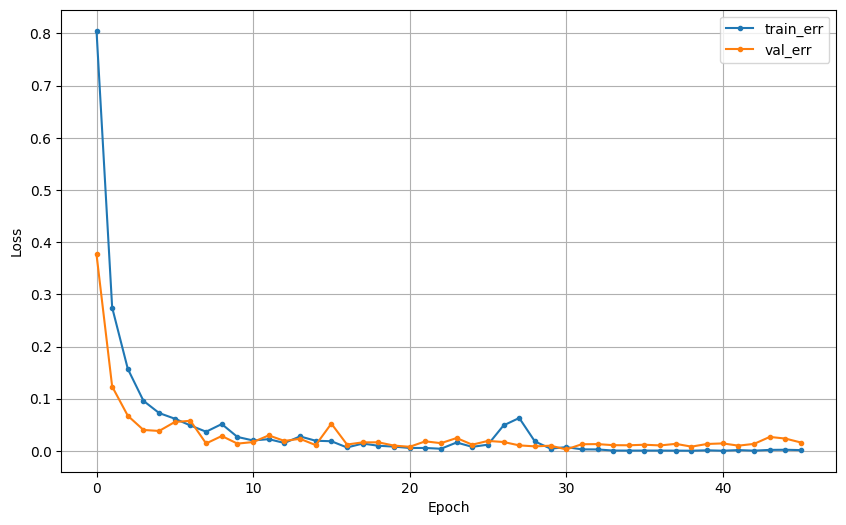

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
0.9949685534591195
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       287
           1       1.00      0.99      1.00       241
           2       0.99      1.00      0.99       267

    accuracy                           0.99       795
   macro avg       1.00      0.99      0.99       795
weighted avg       1.00      0.99      0.99       795

[[285   0   2]
 [  0 239   2]
 [  0   0 267]]


In [ ]:
clear_session()

model_d2 = Sequential([Input(shape=(nf,)),
                       Dense(256, activation='relu'),
                       Dropout(0.2),
                       Dense(64, activation='relu'),
                       Dense(16, activation='relu'),
                       Dense(3, activation='softmax')
                       ])

model_d2.summary()

model_d2.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

min_de = 0.0001
pat = 15

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result_d2 = model_d2.fit(x_train_d, y_train_d, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

dl_history_plot(result_d2)

pred_d2 = model_d2.predict(x_val_d)
pred_d2 = np.argmax(pred_d2, axis=1)

print(accuracy_score(y_val_d, pred_d2))
print(classification_report(y_val_d, pred_d2))
print(confusion_matrix(y_val_d, pred_d2))

In [ ]:
accuracies = []

for _ in range(5):
  clear_session()

  model_d2 = Sequential([Input(shape=(nf,)),
                       Dense(256, activation='relu'),
                       Dropout(0.2),
                       Dense(64, activation='relu'),
                       Dense(16, activation='relu'),
                       Dense(3, activation='softmax')
                       ])
  model_d2.summary()

  model_d2.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

  min_de = 0.0001
  pat = 15

  es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

  model_d2.fit(x_train_d, y_train_d, epochs=100, validation_split=0.2, verbose=0, callbacks=[es])

  pred_d2 = model_d2.predict(x_val_d)
  pred_d2 = np.argmax(pred_d2, axis=1)

  accuracies.append(accuracy_score(y_val_d, pred_d2))

accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         143,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,411 (630.51 KB)

 Trainable params: 161,411 (630.51 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 161,411 (630.51 KB)

 Trainable params: 161,411 (630.51 KB)

 Non-trainable params: 0 (0.00 B)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


[0.9937106918238994,
 0.9962264150943396,
 0.9962264150943396,
 0.9924528301886792,
 0.9911949685534591]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         143,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 187,203 (731.26 KB)

 Trainable params: 187,203 (731.26 KB)

 Non-trainable params: 0 (0.00 B)

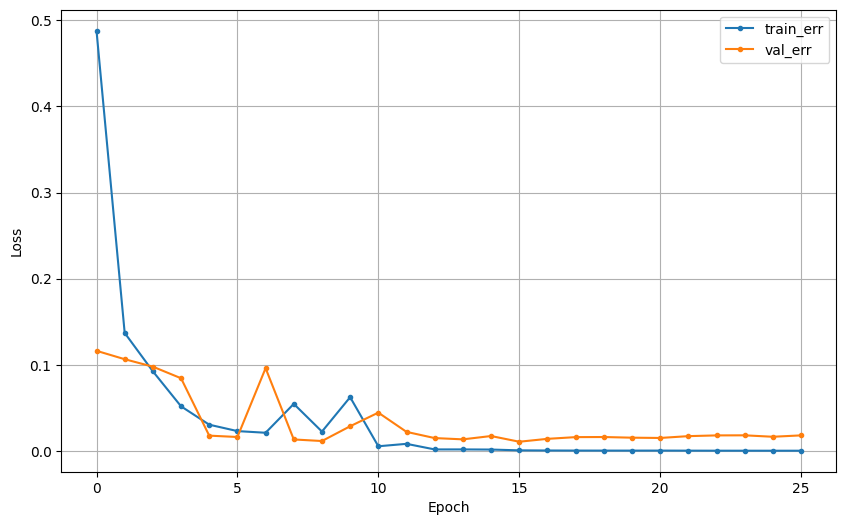

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
0.9949685534591195
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       287
           1       1.00      1.00      1.00       241
           2       0.99      1.00      0.99       267

    accuracy                           0.99       795
   macro avg       0.99      1.00      1.00       795
weighted avg       1.00      0.99      0.99       795

[[283   1   3]
 [  0 241   0]
 [  0   0 267]]


In [ ]:
clear_session()

model_d3 = Sequential([Input(shape=(nf,)),
                       Dense(256, activation='relu'),
                       Dense(128, activation='relu'),
                       Dense(64, activation='relu'),
                       Dense(32, activation='relu'),
                       Dense(3, activation='softmax')
                       ])

model_d3.summary()

model_d3.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

min_de = 0.0001
pat = 10

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result_d3 = model_d3.fit(x_train_d, y_train_d, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

dl_history_plot(result_d3)

pred_d3 = model_d3.predict(x_val_d)
pred_d3 = np.argmax(pred_d3, axis=1)

print(accuracy_score(y_val_d, pred_d3))
print(classification_report(y_val_d, pred_d3))
print(confusion_matrix(y_val_d, pred_d3))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,059 (144.76 KB)

 Trainable params: 37,059 (144.76 KB)

 Non-trainable params: 0 (0.00 B)

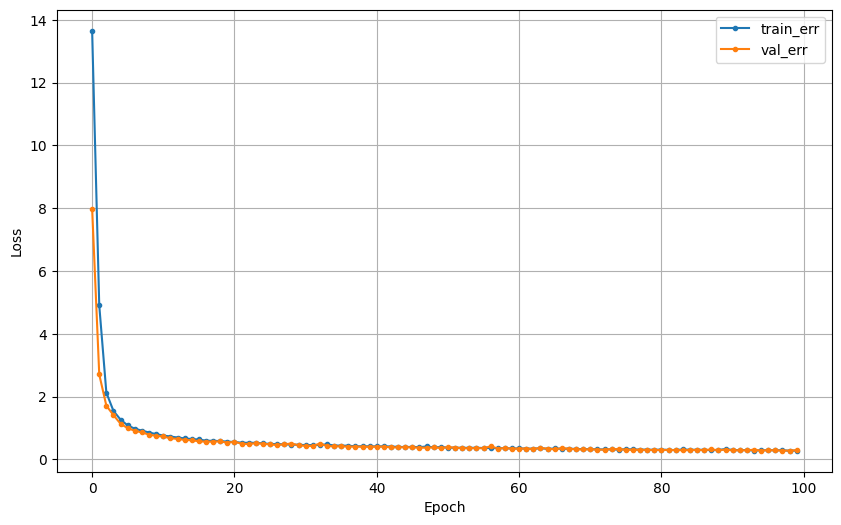

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.9761006289308176
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       287
           1       0.96      0.99      0.97       241
           2       0.97      0.98      0.98       267

    accuracy                           0.98       795
   macro avg       0.98      0.98      0.98       795
weighted avg       0.98      0.98      0.98       795

[[276   6   5]
 [  0 238   3]
 [  1   4 262]]


In [ ]:
clear_session()

model_d4 = Sequential([Input(shape=(nf,)),
                       Dense(64, activation='relu', kernel_regularizer = l1(0.01)),
                       Dense(16, activation='relu', kernel_regularizer = l1(0.01)),
                       Dense(3, activation='softmax')
                       ])

model_d4.summary()

model_d4.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

min_de = 0.0001
pat = 15

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result_d4 = model_d4.fit(x_train_d, y_train_d, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

dl_history_plot(result_d4)

pred_d4 = model_d4.predict(x_val_d)
pred_d4 = np.argmax(pred_d4, axis=1)

print(accuracy_score(y_val_d, pred_d4))
print(classification_report(y_val_d, pred_d4))
print(confusion_matrix(y_val_d, pred_d4))


### (3) 분류 모델 파이프라인 구성


* 세부 요구사항
    * 두 단계 모델을 통합하고, 새로운 데이터(test)에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
    * 데이터 파이프라인 구축 : test데이터가 로딩되어 전처리 과정을 거치고, 예측 및 성능 평가 수행

* 예시
![](https://github.com/DA4BAM/image/blob/main/pipeline%20function.png?raw=true)

#### 1) 함수 만들기

In [ ]:
def compined_pipeline(data, model_stage, model_static, model_dynamic):
  target = 'is_dynamic'
  x_ds = data_d.drop(columns=target)
  y_ds = data_d[target]

  scaler = MinMaxScaler()
  x_ds_s = scaler.fit_transform(x_ds)

  is_dynamic_proba = model_stage.predict(x_ds_s)
  is_dynamic = np.where(is_dynamic_proba>0.5, 1, 0)

  static_indices = (is_dynamic == 0)
  x_static = x_ds_s[static_indices, :]
  y_static = y_ds[static_indices]

  if len(x_static) > 0:
      # 정적 행동에 대한 예측
      y_pred_static_proba = model_static.predict(x_static)
      y_pred_static = np.argmax(y_pred_static_proba, axis=1)  # 각 행에 대해 최대값 선택

      # 정적 행동 예측 결과를 라벨로 변환
      y_pred_static_labels = [ ['LAYING', 'SITTING', 'STANDING'][i] for i in y_pred_static ]

      # 정확도 계산
      static_acc = accuracy_score(y_static, y_pred_static_labels)
      print(f'정적 행동 정확도: {static_acc}')
  else:
      y_pred_static_labels = []
      print("정적 행동 데이터가 없습니다.")

In [ ]:
def act_classification_pipeline(test_data, model_stage, model_static, model_dynamic):
    # is_dynamic = y.map({'STANDING':0, 'SITTING':0, 'LAYING':0,
    #               'WALKING':1, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':1})
    # 1. 데이터 전처리
    print("Step 1: 데이터 전처리 시작")
    x_test = test_data.drop(columns=target)  # Activity 제거
    y_test = test_data.loc[:, target]

    # 데이터 스케일링 (MinMaxScaler 사용)
    #scaler = MinMaxScaler()
    #x_test_s = scaler.fit_transform(x_test)
    x_test_s = scaler1.transform(x_test)
    print(f"x_test_s shape: {x_test_s.shape}")
    print(f"y_test shape: {y_test.shape}")

    # 2. 정적 / 동적 분류
    print("Step 2: 정적 / 동적 분류 시작")
    is_dynamic_proba = model_stage.predict(x_test_s)
    is_dynamic = np.where(is_dynamic_proba>0.5, 1, 0)
    print(f"is_dynamic 분류 결과 (0: 정적, 1: 동적): {np.unique(is_dynamic, return_counts=True)}")

    # 3 - 1. 정적 행동 분류
    static_indices = (is_dynamic == 0)
    print(static_indices)
    print(x_test_s)
    x_test_static = x_test_s[static_indices, :]
    y_test_static = y_test[static_indices]
    print(f"x_test_static shape: {x_test_static.shape}, y_test_static shape: {y_test_static.shape}")

    if len(x_test_static) > 0:
        # 정적 행동에 대한 예측
        y_pred_static_proba = model_static.predict(x_test_static)
        y_pred_static = np.argmax(y_pred_static_proba, axis=1)  # 각 행에 대해 최대값 선택

        # 정적 행동 예측 결과를 라벨로 변환
        y_pred_static_labels = [ ['LAYING', 'SITTING', 'STANDING'][i] for i in y_pred_static ]

        # 정확도 계산
        static_acc = accuracy_score(y_test_static, y_pred_static_labels)
        print(f'정적 행동 정확도: {static_acc}')
    else:
        y_pred_static_labels = []
        print("정적 행동 데이터가 없습니다.")

    # 3 - 2. 동적 행동 분류
    dynamic_indices = (is_dynamic == 1)
    x_test_dynamic = x_test_s[dynamic_indices, :]
    y_test_dynamic = y_test[dynamic_indices]
    print(x_test_dynamic)
    if len(x_test_dynamic) > 0:
        # 동적 행동에 대한 예측
        y_pred_dynamic_proba = model_dynamic.predict(x_test_dynamic)
        y_pred_dynamic = np.argmax(y_pred_dynamic_proba, axis=1)  # 각 행에 대해 최대값 선택

        # 동적 행동 예측 결과를 라벨로 변환
        y_pred_dynamic_labels = [ ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'][i] for i in y_pred_dynamic ]

        # 정확도 계산
        dynamic_acc = accuracy_score(y_test_dynamic, y_pred_dynamic_labels)
        print(f'동적 행동 정확도: {dynamic_acc}')
    else:
        y_pred_dynamic_labels = []
        print("동적 행동 데이터가 없습니다.")

    # 4. 예측 결과 합치기
    final_pred = np.zeros_like(is_dynamic, dtype=object)

    if len(y_pred_static_labels) > 0:
        final_pred[static_indices] = y_pred_static_labels
    if len(y_pred_dynamic_labels) > 0:
        final_pred[dynamic_indices] = y_pred_dynamic_labels

    # 5. 전체적인 성능 평가
    overall_acc = accuracy_score(y_test, final_pred)
    print(f'전체 모델 정확도: {overall_acc}')
    print(classification_report(y_test, final_pred))
    print(confusion_matrix(y_test, final_pred))

    return final_pred

#### 2) test 셋으로 예측하고 평가하기